# TS2 - Simulación de un ADC con Ruido 
Catalina Wynne

## Consigna
En esta tarea semanal retomamos la consigna de la tarea anterior, donde simulamos el bloque de cuantización de un ADC de B bits en un rango de  ±VF
 Volts. Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a fs Hertz.

Para ello se simulará el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

Frecuencia f0 arbitraria, por ejemplo f0=fS/N=Δf
 
Energía normalizada, es decir energía (o varianza) unitaria

Con respecto a los parámetros de la secuencia de ruido, diremos que:

Será de carácter aditivo, es decir la señal que entra al ADC será sR=s+n. Siendo n
la secuencia que simula la interferencia, y s la senoidal descrita anteriormente. 
 
La potencia del ruido será Pn=kn.Pq W siendo el factor k una escala para la potencia del ruido de cuantización Pq=q212.
 
Finalmente, n será incorrelado y Gaussiano.

El ADC que deseamos simular trabajará a una frecuencia de muestreo fS=1000
 Hz y tendrá un rango analógico de ±VF=2 Volts.

Se pide:

a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1.

b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}
. Discutir los resultados respecto a lo obtenido en a).

## Introducción
En este trabajo se simula el proceso completo de digitalización de una señal mediante un ADC realista.

Se analizan como afectan la señal en el tiempo, el espectro en frecuencia y la distribución del error a a la señal muestreada.

# Ejercicio 1

## Definición de señal senoidal

La expresión general es:

                       x(t) = A*sin(2* π*f*t + ϕ) + DC

donde: 

A: amplitud

f: frecuencia (Hz);

ph : fase (ϕ);

DC : valor medio.


## Función senoidal

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs
    tt = np.arange(nn) * ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

## Parámetros de base

In [2]:
fs = 1000
nn = 1000
ff = fs/nn

vmax = np.sqrt(2)  # potencia unitaria
dc = 0
ph = 0

tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)

## Generación de señal + ruido + cuantización

In [3]:
B = 4
Vfs = 2

qq = (2 * Vfs) / (2**B)
Pq = (qq**2) / 12

kn = 1
potencia_ruido = kn * Pq

ruido = np.random.normal(0, np.sqrt(potencia_ruido), nn)
yy = xx + ruido

xxq = np.round(yy / qq) * qq

## Gráfico de señales

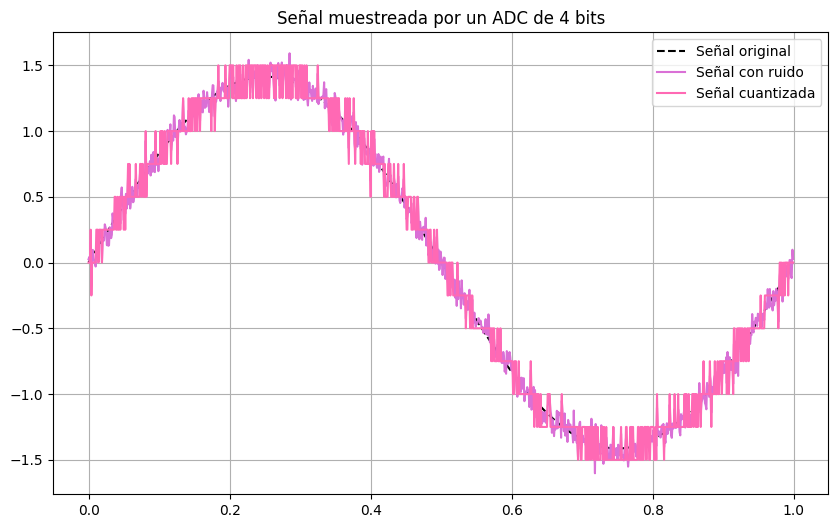

In [4]:
plt.figure(figsize=(10,6))
plt.plot(tt, xx, '--', color='black', label='Señal original')
plt.plot(tt, yy, color='orchid', label='Señal con ruido')
plt.plot(tt, xxq, color='hotpink', label='Señal cuantizada')
plt.title("Señal muestreada por un ADC de 4 bits")
plt.legend()
plt.grid()
plt.show()

#### Análisis de la señal de tiempo
En este gráfico se observan tres señales: la señal original, la señal con ruido y la señal cuantizada.

La señal original es una senoidal perfecta, suave y periódica, que representa la entrada ideal al sistema.
Al agregar ruido gaussiano, la señal presenta pequeñas variaciones aleatorias alrededor de su valor original, lo que genera una leve distorsión pero sin alterar su forma general.

La señal cuantizada presenta un comportamiento escalonado, producto del proceso de discretización del ADC. Debido a que se trabaja con una resolución de 4 bits, los niveles de cuantización son relativamente pocos, por lo que la señal se ve notablemente deformada respecto de la original.

Se observa que el error total es resultado de la combinación del ruido analógico y la cuantización, siendo ambos efectos comparables en este caso (kn = 1).



## Espectro de potencia 

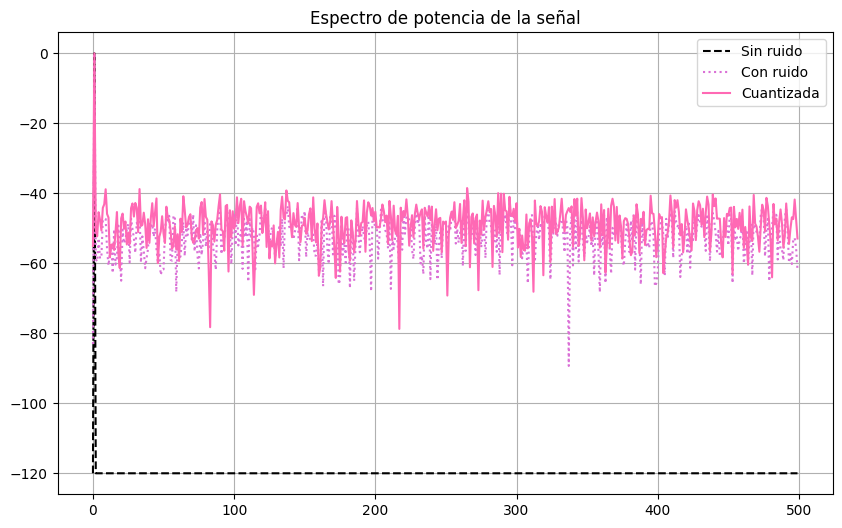

In [5]:
def espectro(signal):
    FFT = np.fft.fft(signal)
    mod = np.abs(FFT) / nn
    pot = 2 * (mod**2)
    return 10*np.log10(pot + 1e-12)

esp_x = espectro(xx)
esp_y = espectro(yy)
esp_q = espectro(xxq)

plt.figure(figsize=(10,6))
plt.plot(esp_x[:nn//2], color='black', linestyle='--', label='Sin ruido')
plt.plot(esp_y[:nn//2], color='orchid', linestyle=':', label='Con ruido')
plt.plot(esp_q[:nn//2], color='hotpink', label='Cuantizada')
plt.title("Espectro de potencia de la señal")
plt.legend()
plt.grid()
plt.show()

### Analisis del espectro de potencia 
En el espectro de la señal original se observa un pico bien definido en la frecuencia de la senoidal, sin presencia de ruido de fondo.

Al incorporar ruido, aparece un piso de ruido distribuido en todo el espectro, característico del ruido blanco, mientras que el pico de la señal se mantiene visible.

En la señal cuantizada también se observa un piso de ruido, correspondiente al error de cuantización. Este piso es similar al del ruido analógico debido a que kn = 1, lo que indica que ambos tipos de ruido tienen magnitudes comparables.

Esto muestra que en este caso el sistema se encuentra en una condición de equilibrio entre ruido analógico y ruido de cuantización.


## Histograma del error 


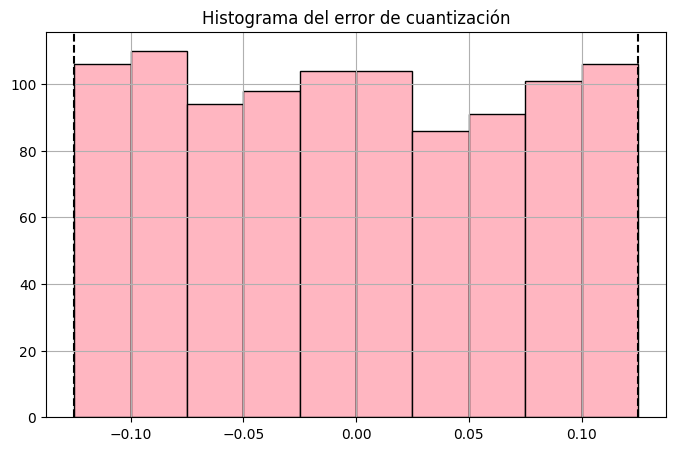

In [6]:
error = xxq - yy

plt.figure(figsize=(8,5))
plt.hist(error, bins=10, range=(-qq/2, qq/2), color='lightpink', edgecolor='black')
plt.axvline(-qq/2, color='black', linestyle='--')
plt.axvline(qq/2, color='black', linestyle='--')
plt.title("Histograma del error de cuantización")
plt.grid()
plt.show()


### Analísis del histograma del error 
El histograma representa la distribución del error de cuantización, definido como la diferencia entre la señal cuantizada y la señal de entrada al ADC.

Se observa que el error se encuentra acotado dentro del intervalo ±q/2, tal como predice la teoría.

La distribución es aproximadamente uniforme, lo que indica que el modelo de ruido de cuantización uniforme es válido en este caso. Sin embargo, pueden observarse pequeñas desviaciones debido a la presencia de ruido analógico.

# Ejercicio 2

## B = 4 Bits


## Señales

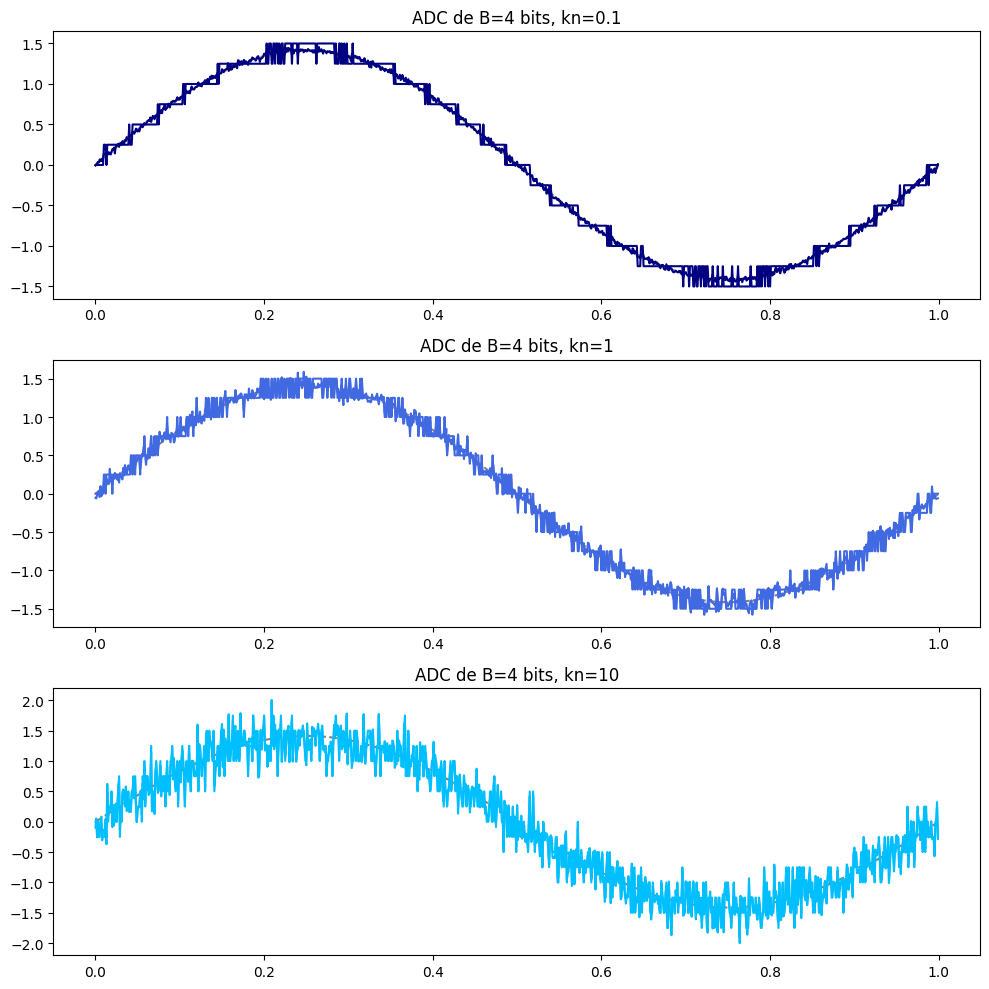

In [7]:
B = 4
qq = (2 * Vfs) / (2**B)
Pq = (qq**2) / 12
fig, axs = plt.subplots(3,1, figsize=(10,10))

# kn = 0.1
kn = 0.1
ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
yy = xx + ruido
xxq = np.round(yy/qq)*qq
axs[0].plot(tt, xx, '--', color='gray')
axs[0].plot(tt, yy, color='navy')
axs[0].plot(tt, xxq, color='navy')
axs[0].set_title("ADC de B=4 bits, kn=0.1")

# kn = 1
kn = 1
ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
yy = xx + ruido
xxq = np.round(yy/qq)*qq
axs[1].plot(tt, xx, '--', color='gray')
axs[1].plot(tt, yy, color='royalblue')
axs[1].plot(tt, xxq, color='royalblue')
axs[1].set_title("ADC de B=4 bits, kn=1")

# kn = 10
kn = 10
ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
yy = xx + ruido
xxq = np.round(yy/qq)*qq
axs[2].plot(tt, xx, '--', color='gray')
axs[2].plot(tt, yy, color='deepskyblue')
axs[2].plot(tt, xxq, color='deepskyblue')
axs[2].set_title("ADC de B=4 bits, kn=10")

plt.tight_layout()
plt.show()

### Análisis de las señales
Para k = 0.1

En este caso el ruido analógico es bajo respecto al ruido de cuantización.

La señal con ruido es muy similar a la original, ya que la perturbación es pequeña. Sin embargo, la señal cuantizada sigue presentando escalones marcados, lo que indica que el error dominante es el de cuantización.

Se concluye que el sistema está limitado por la resolución del ADC.

Para k = 1

El ruido analógico y el ruido de cuantización tienen magnitudes similares.

La señal con ruido presenta variaciones visibles, y la señal cuantizada combina tanto el efecto del ruido como el escalonamiento.

Se observa un compromiso entre ambos tipos de degradación.

Para k = 10

El ruido analógico es dominante en este caso.

La señal con ruido se encuentra fuertemente perturbada, perdiendo claridad respecto a la senoidal original. La cuantización tiene un efecto menor en comparación con el ruido.

Se concluye que mejorar la cantidad de bits no tendría un impacto significativo en este escenario.



### Espectros de potencia

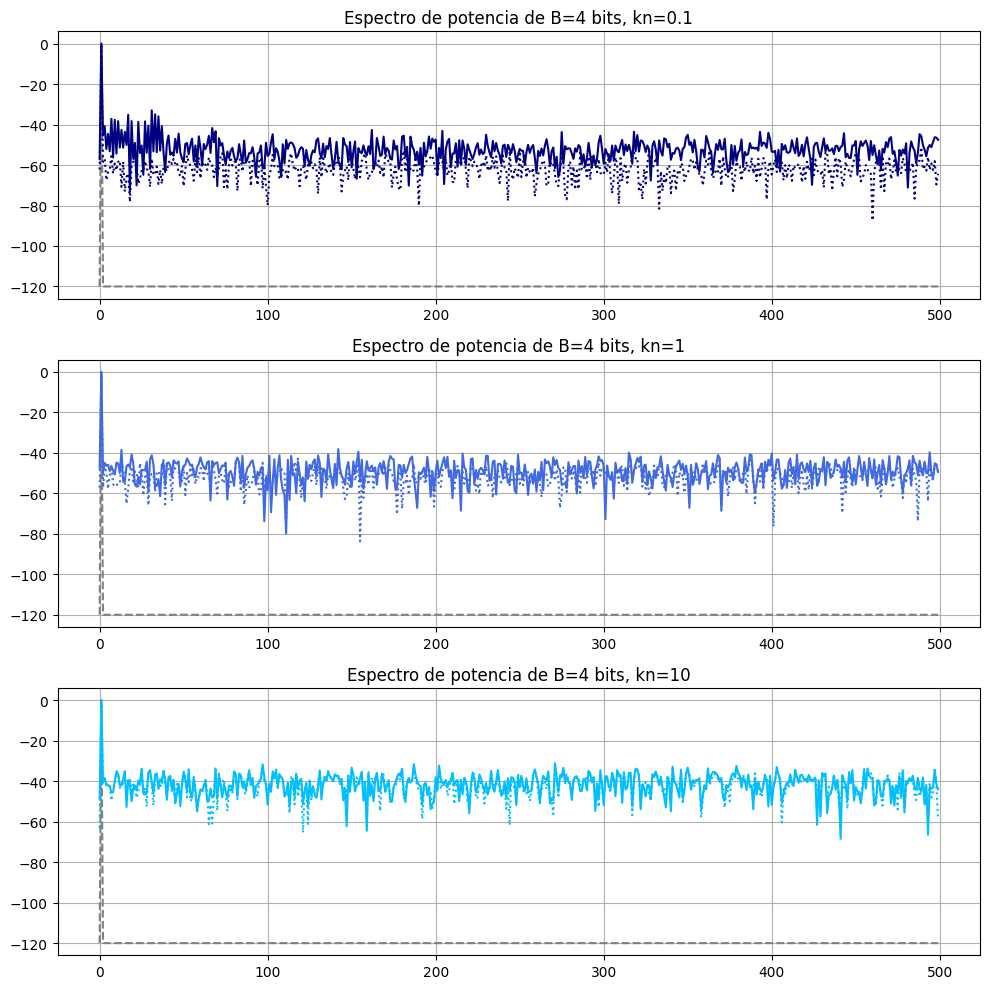

In [8]:
fig, axs = plt.subplots(3,1, figsize=(10,10))

def plot_esp(ax, kn,color):
    ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
    yy = xx + ruido
    xxq = np.round(yy/qq)*qq      

    ax.plot(espectro(xx)[:nn//2], '--', color='gray')
    ax.plot(espectro(yy)[:nn//2], ':', color= color)
    ax.plot(espectro(xxq)[:nn//2], color= color)
    ax.set_title(f"Espectro de potencia de B=4 bits, kn={kn}")
    ax.grid()

plot_esp(axs[0], 0.1,'navy')
plot_esp(axs[1], 1,'royalblue')
plot_esp(axs[2], 10,'deepskyblue')

plt.tight_layout()
plt.show()

### Análisis de las potencias de espectro

Para kn = 0.1, el piso de ruido está determinado principalmente por la cuantización.
Para kn = 1, ambos pisos de ruido son comparables.
Para kn = 10, el piso de ruido está dominado por el ruido analógico.

En todos los casos, el pico de la señal sigue siendo visible, pero la relación señal-ruido se degrada a medida que aumenta kn.



### Histograma del error 

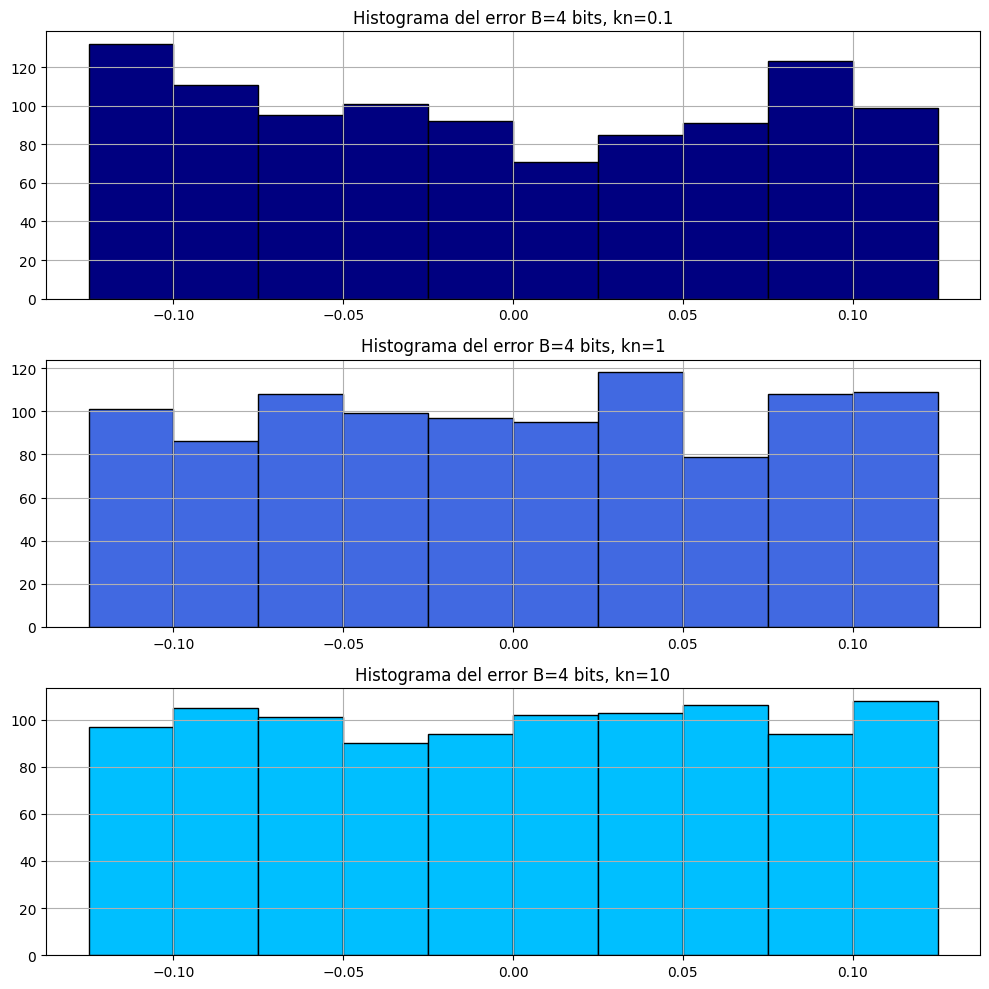

In [9]:
fig, axs = plt.subplots(3,1, figsize=(10,10))

def plot_hist(ax, kn,color):
    ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
    yy = xx + ruido
    xxq = np.round(yy/qq)*qq
    error = xxq - yy

    ax.hist(error, bins=10, range=(-qq/2, qq/2),
            color=color, edgecolor='black')
    ax.set_title(f"Histograma del error B=4 bits, kn={kn}")
    ax.grid()

plot_hist(axs[0], 0.1,'navy')
plot_hist(axs[1], 1,'royalblue')
plot_hist(axs[2], 10,'deepskyblue')

plt.tight_layout()
plt.show()

### Análisis de los histogramas del error 

Para kn = 0.1, el histograma presenta una forma uniforme clara, indicando un comportamiento ideal del error de cuantización.

Para kn = 1, la distribución sigue siendo aproximadamente uniforme, aunque con mayor dispersión.

Para kn = 10, la distribución se ve más distorsionada debido a la influencia del ruido analógico.


## B = 8 Bits

## Señales

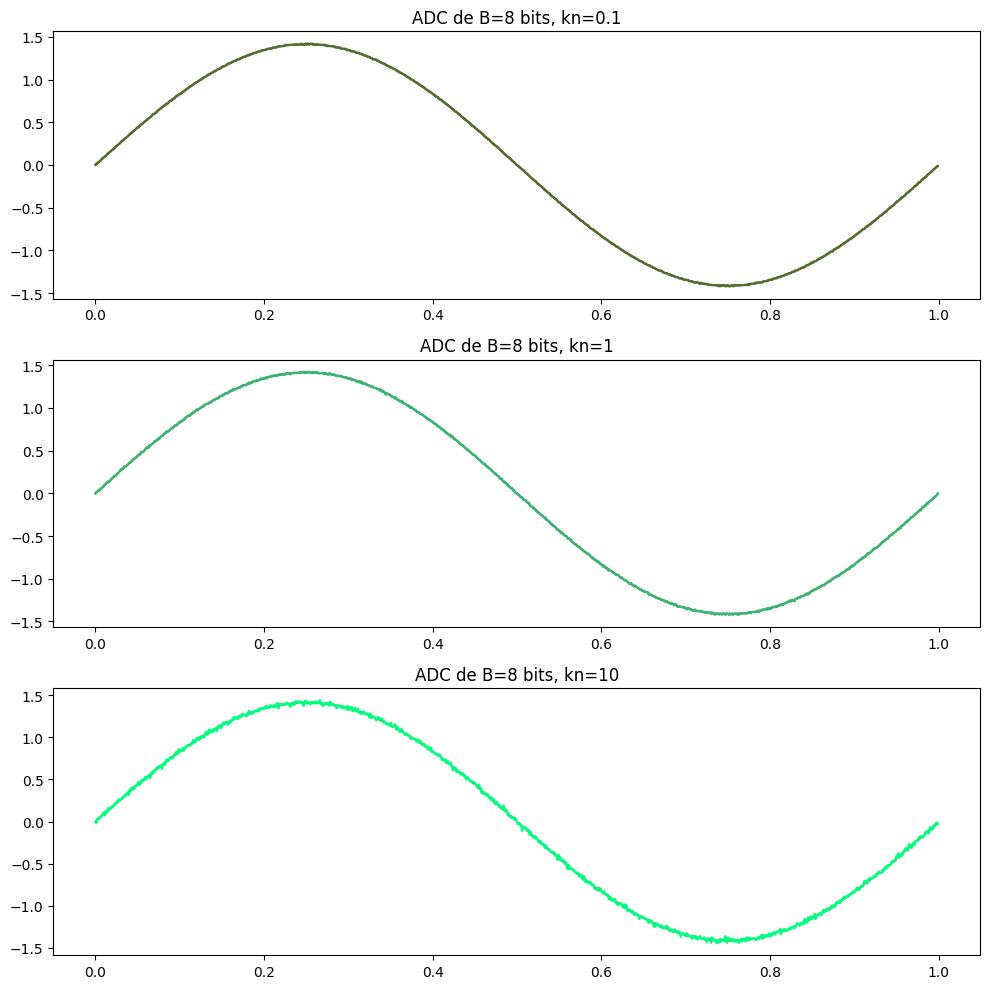

In [10]:
B = 8
qq = (2 * Vfs) / (2**B)
Pq = (qq**2) / 12
fig, axs = plt.subplots(3,1, figsize=(10,10))

# kn = 0.1
kn = 0.1
ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
yy = xx + ruido
xxq = np.round(yy/qq)*qq
axs[0].plot(tt, xx, '--', color='gray')
axs[0].plot(tt, yy, color='darkolivegreen')
axs[0].plot(tt, xxq, color='darkolivegreen')
axs[0].set_title("ADC de B=8 bits, kn=0.1")

# kn = 1
kn = 1
ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
yy = xx + ruido
xxq = np.round(yy/qq)*qq
axs[1].plot(tt, xx, '--', color='gray')
axs[1].plot(tt, yy, color='mediumseagreen')
axs[1].plot(tt, xxq, color='mediumseagreen')
axs[1].set_title("ADC de B=8 bits, kn=1")

# kn = 10
kn = 10
ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
yy = xx + ruido
xxq = np.round(yy/qq)*qq
axs[2].plot(tt, xx, '--', color='gray')
axs[2].plot(tt, yy, color='springgreen')
axs[2].plot(tt, xxq, color='springgreen')
axs[2].set_title("ADC de B=8 bits, kn=10")

plt.tight_layout()
plt.show()

### Análisis de las señales

Al aumentar la cantidad de bits, los niveles de cuantización son más finos.

La señal cuantizada se aproxima mucho mejor a la señal original, reduciendo significativamente el error de cuantización.

El comportamiento frente a kn se mantiene, pero ahora el ruido analógico tiene mayor protagonismo relativo.

### Espectro de potencia

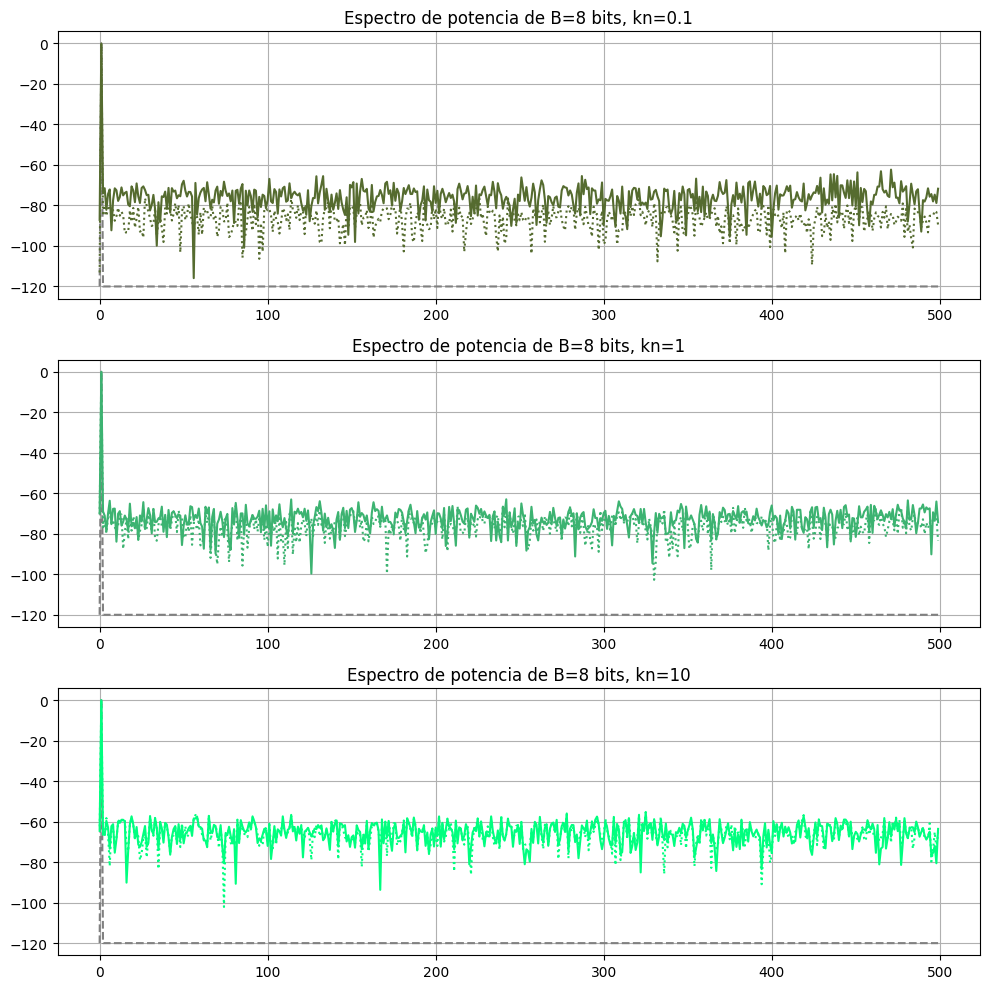

In [11]:
fig, axs = plt.subplots(3,1, figsize=(10,10))

def plot_esp(ax, kn,color):
    ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
    yy = xx + ruido
    xxq = np.round(yy/qq)*qq

    ax.plot(espectro(xx)[:nn//2], '--', color='gray')
    ax.plot(espectro(yy)[:nn//2], ':', color=color)
    ax.plot(espectro(xxq)[:nn//2], color=color)
    ax.set_title(f"Espectro de potencia de B=8 bits, kn={kn}")
    ax.grid()

plot_esp(axs[0], 0.1,'darkolivegreen')
plot_esp(axs[1], 1,'mediumseagreen')
plot_esp(axs[2], 10,'springgreen')

plt.tight_layout()
plt.show()

### Análisis del espectro de potencia
El piso de ruido de cuantización disminuye respecto al caso de 4 bits.

Esto permite observar con mayor claridad cuándo domina el ruido analógico, especialmente para valores altos de kn.


### Histograma del error 

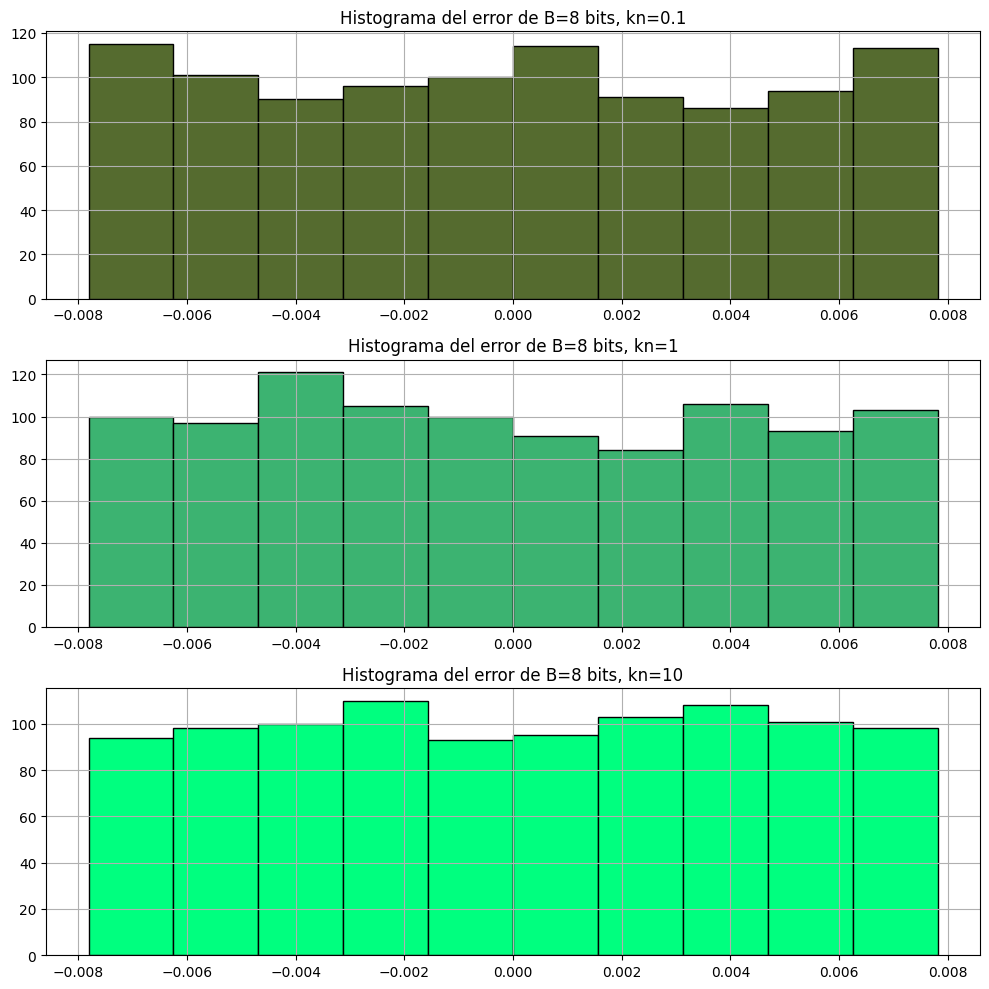

In [12]:
fig, axs = plt.subplots(3,1, figsize=(10,10))

def plot_hist(ax, kn,color):
    ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
    yy = xx + ruido
    xxq = np.round(yy/qq)*qq
    error = xxq - yy

    ax.hist(error, bins=10, range=(-qq/2, qq/2),
            color=color, edgecolor='black')
    ax.set_title(f"Histograma del error de B=8 bits, kn={kn}")
    ax.grid()

plot_hist(axs[0], 0.1,'darkolivegreen')
plot_hist(axs[1], 1,'mediumseagreen')
plot_hist(axs[2], 10,'springgreen')

plt.tight_layout()
plt.show()


### Análisis del histograma del error 
El rango del error de cuantización se reduce notablemente.

La distribución continúa siendo uniforme, pero más concentrada alrededor de cero.

## B = 16 Bits 

### Señales

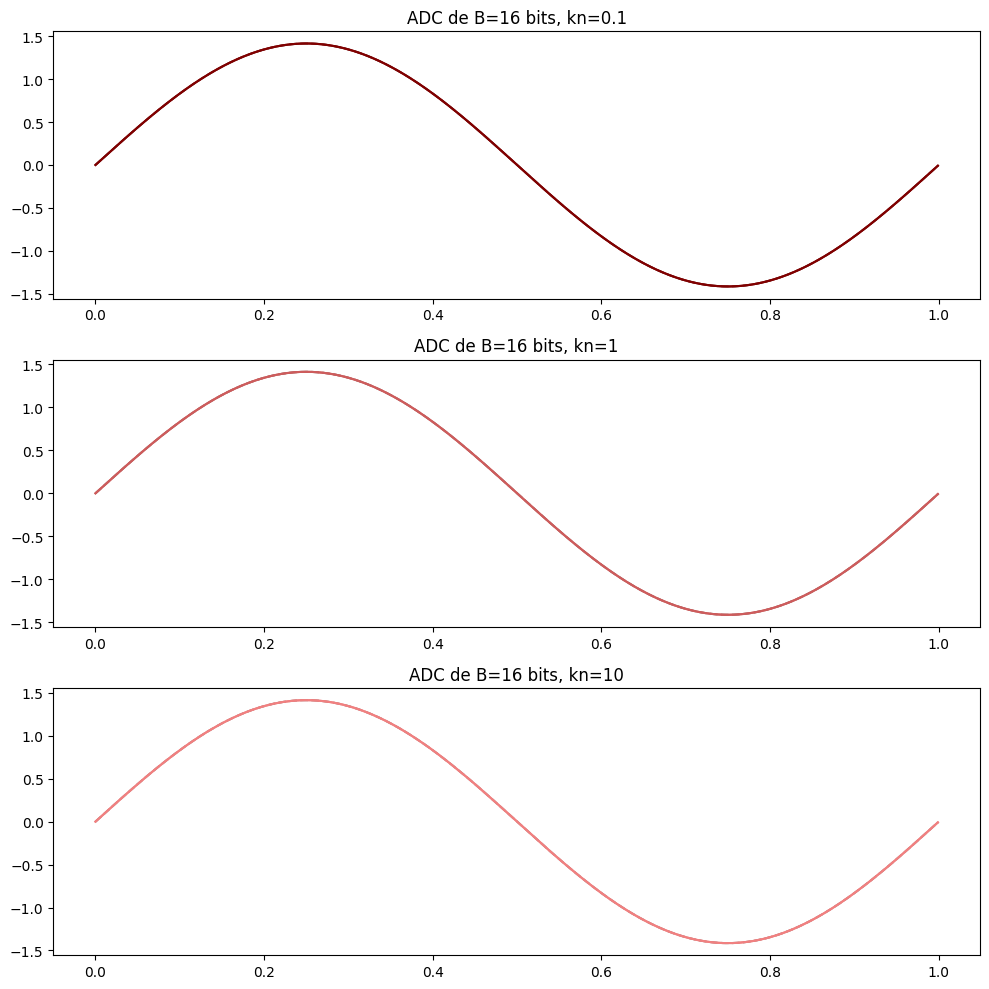

In [13]:
B = 16
qq = (2 * Vfs) / (2**B)
Pq = (qq**2) / 12
fig, axs = plt.subplots(3,1, figsize=(10,10))

# kn = 0.1
kn = 0.1
ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
yy = xx + ruido
xxq = np.round(yy/qq)*qq
axs[0].plot(tt, xx, '--', color='gray')
axs[0].plot(tt, yy, color='maroon')
axs[0].plot(tt, xxq, color='maroon')
axs[0].set_title("ADC de B=16 bits, kn=0.1")

# kn = 1
kn = 1
ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
yy = xx + ruido
xxq = np.round(yy/qq)*qq
axs[1].plot(tt, xx, '--', color='gray')
axs[1].plot(tt, yy, color='indianred')
axs[1].plot(tt, xxq, color='indianred')
axs[1].set_title("ADC de B=16 bits, kn=1")

# kn = 10
kn = 10
ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
yy = xx + ruido
xxq = np.round(yy/qq)*qq
axs[2].plot(tt, xx, '--', color='gray')
axs[2].plot(tt, yy, color='lightcoral')
axs[2].plot(tt, xxq, color='lightcoral')
axs[2].set_title("ADC de B=16 bits, kn=10")

plt.tight_layout()
plt.show()

### Análisis de la señal 
La cuantización es prácticamente imperceptible.

La señal cuantizada es casi indistinguible de la señal con ruido, lo que indica que el error de cuantización es despreciable.

### Espectro de potencia

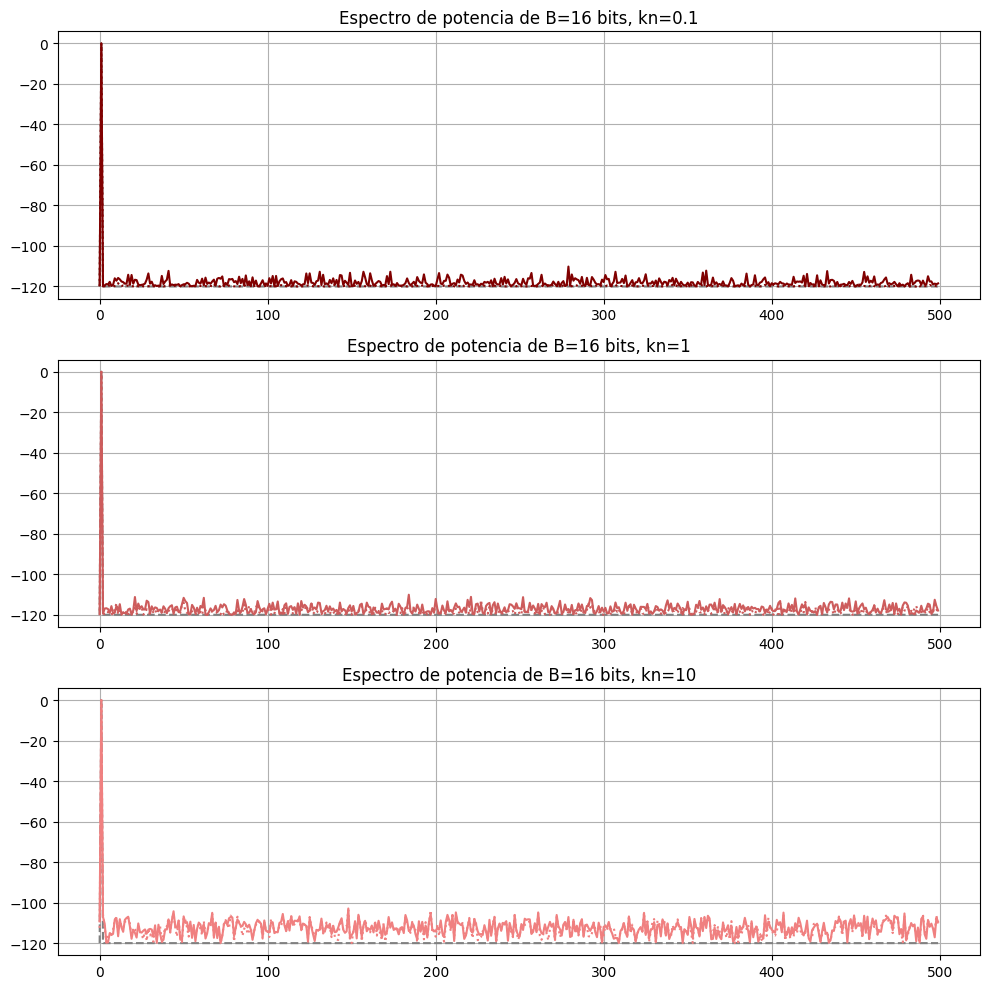

In [14]:
fig, axs = plt.subplots(3,1, figsize=(10,10))

def plot_esp(ax, kn,color):
    ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
    yy = xx + ruido
    xxq = np.round(yy/qq)*qq

    ax.plot(espectro(xx)[:nn//2], '--', color= 'gray')
    ax.plot(espectro(yy)[:nn//2], ':', color=color)
    ax.plot(espectro(xxq)[:nn//2], color=color)
    ax.set_title(f"Espectro de potencia de B=16 bits, kn={kn}")
    ax.grid()

plot_esp(axs[0], 0.1,'maroon')
plot_esp(axs[1], 1,'indianred')
plot_esp(axs[2], 10,'lightcoral')

plt.tight_layout()
plt.show()

### Análisis del espectro de potencia
El piso de cuantización es extremadamente bajo.

El espectro está dominado completamente por el ruido analógico en la mayoría de los casos.

### Histograma del error

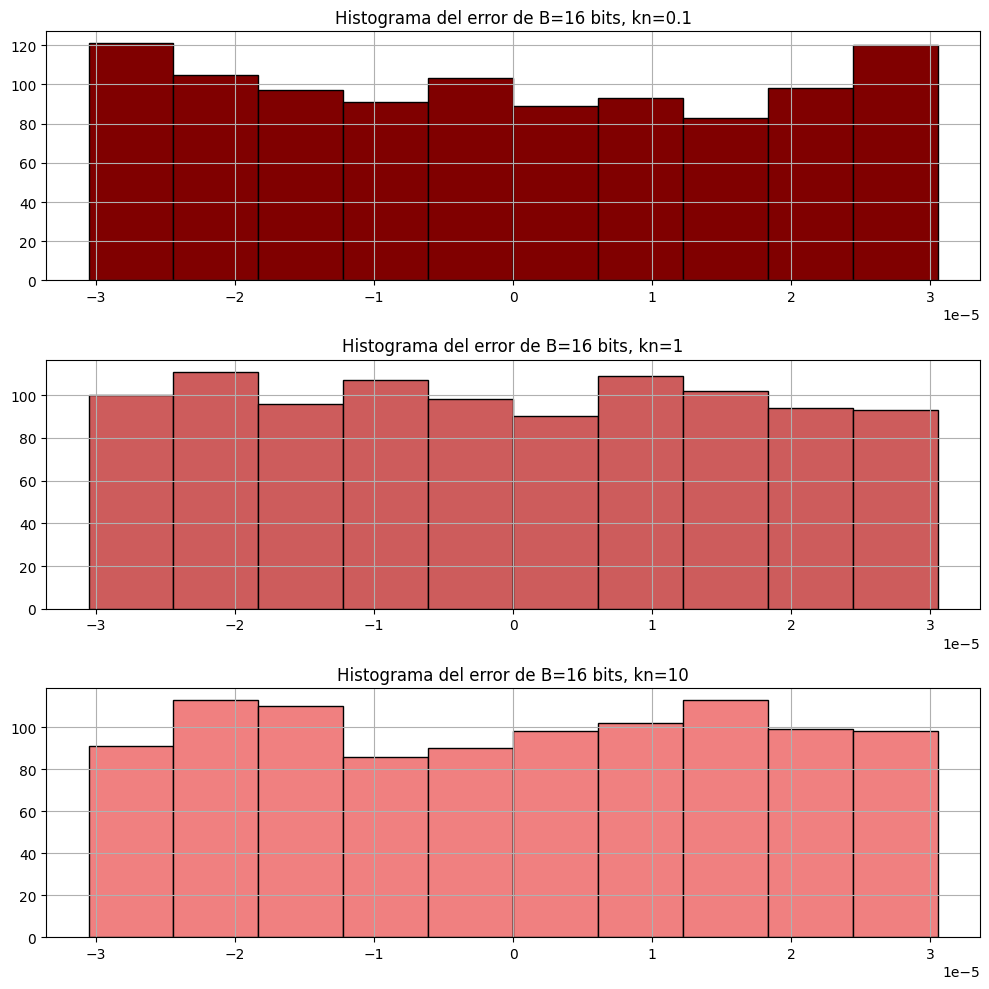

In [15]:
fig, axs = plt.subplots(3,1, figsize=(10,10))

def plot_hist(ax, kn,color):
    ruido = np.random.normal(0, np.sqrt(kn*Pq), nn)
    yy = xx + ruido
    xxq = np.round(yy/qq)*qq
    error = xxq - yy

    ax.hist(error, bins=10, range=(-qq/2, qq/2),
            color=color, edgecolor='black')
    ax.set_title(f"Histograma del error de B=16 bits, kn={kn}")
    ax.grid()

plot_hist(axs[0], 0.1,'maroon')
plot_hist(axs[1], 1,'indianred')
plot_hist(axs[2], 10,'lightcoral')

plt.tight_layout()
plt.show()

### Análisis del histograma del error 
El error de cuantización es muy pequeño.

El histograma aparece altamente concentrado en torno a cero, manteniendo forma aproximadamente uniforme pero en un rango muy reducido.

### Conclusiones finales
En este trabajo se analizó el proceso de digitalización de una señal mediante un ADC, considerando tanto el efecto del ruido analógico como el error de cuantización.

A partir de las simulaciones realizadas, se pudo observar que la señal digital resultante se ve afectada por dos fuentes principales de degradación, el ruido presente en la entrada del sistema y la discretización impuesta por la cuantozación.

En el ejercicio A, se verificó que para una resolución de 4 bits y un nivel de ruido tal que kn = 1, ambos efectos tienen una influencia comparable. Esto se evidenció tanto en el dominio temporal como en el espectral, donde se observa un equilibrio entre el ruido analógico y el ruido de cuantización. Además, el histograma del error confirmó que la distribución  del error de cuantización es aproximadamente uniforme dentro del intervalo teórico esperado. 

En el ejercicio B, se estudió la influencia de la cantidad de bits del ADC y del nivel de ruido mediante el parámetro kn. Se observó que:

Para valores bajos de kn, el error de cuantización domina el sistema, especialmente cuando la resolución en bits es baja.

Para valores altos de kn, el ruido analógico se vuelve predominante, haciendo que el aumento en la cantidad de bits no genere mejoras significativas en la calidad de la señal.

Existe una condición intermedia donde ambos tipos de ruido son comparables, generando un compromiso entre resolución y ruido.

Asimismo, se comprobó que al aumentar la cantidad de bits del ADC, el paso de cuantización disminuye, reduciendo el error y mejorando la aproximación de la señal digital a la señal original. Esto también se refleja en el espectro, donde el piso de ruido de cuantización desciende notablemente.

Por otro lado, el análisis de los histogramas permitió validar el modelo teórico del error de cuantización como una variable aleatoria uniformemente distribuida, aunque este comportamiento se ve afectado cuando el ruido analógico es significativo.

En conclusión, el desempeño de un ADC no depende únicamente de su resolución, sino también del nivel de ruido presente en la señal de entrada. Esto pone en evidencia la importancia de considerar tanto el diseño del conversor como las condiciones del entorno en aplicaciones reales.
